# Deconvolution of Spatial Wavelet Coefficient Representation of Chromatin Images
February 15, 2024

A notebook to test the idea of whether we can deconvolve wavelet coefficients of the chromatin image data.


In [1]:
# Preamble, notebook setup and imports

%load_ext autoreload
%autoreload 2
%matplotlib inline
%config InlineBackend.figure_format = 'retina'

import numpy as np
import pandas as pd
import matplotlib.pyplot as plt


In [2]:
from cc_src.chromatin_model import ChromatinModel
from src.config import load_yl_replicate1_rg1_alpha_vst_config

gene_name = 'CLB2'
config1 = load_yl_replicate1_rg1_alpha_vst_config()
chromatin_model = ChromatinModel(config1)
chromatin_model.load_mnase_gene(gene_name, 1)

Loading MNase reads for CLB2...Done.


In [147]:
chromatin_model.create_deconvolution_bins(smoothing=False)

Unflattened the input data is of shape: (16, 16, 50)
The size of our input data, G is: (16, 800)


In [148]:
from src.chromatin_wavelets import ChromatinWavelets

chrom_wavelets = ChromatinWavelets(chromatin_model)

In [149]:
chrom_wavelets.create_coefficients()

Created coefficients matrix of shape: (16, 4, 12, 29)
Created coefficients vectorized matrix of shape: (16, 1392)


In [150]:
recon_coefficients_mat = chrom_wavelets.convert_vectorized_coeffs_to_mat(chrom_wavelets.coeffs_vec)

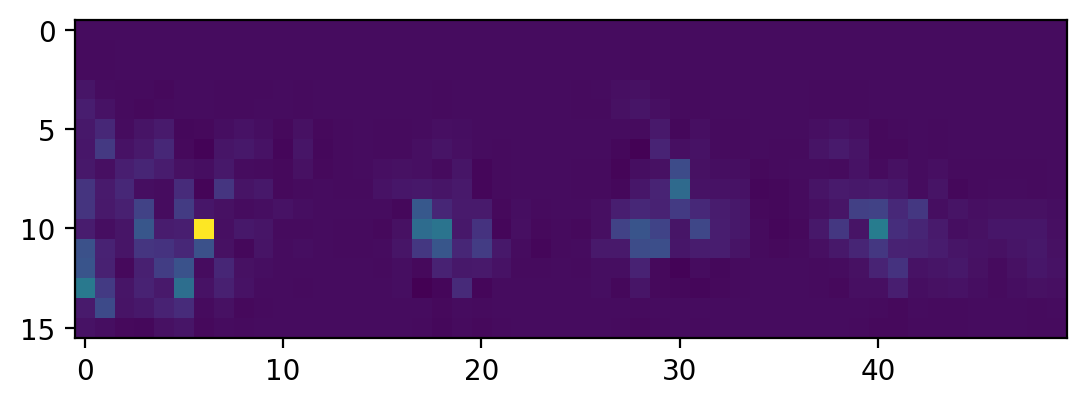

In [151]:
imgs = chrom_wavelets.reconstruct_images(recon_coefficients_mat)
plt.imshow(imgs[0])

In [152]:
# Now, can we deconvolve the coefficients vector?
chromatin_model.setup_deconv_model()
deconv_model = chromatin_model.deconv_model

In [153]:
G = chrom_wavelets.coeffs_vec

In [154]:

# Threshold G, such that there are non negative values
# This effectively compresses the coefficient matrix
# and removes negative values from G which would cause issues with the solver.
G = chrom_wavelets.coeffs_vec.copy()
G[G < 0] = 0


In [157]:
from src.deconvolve_chromatin import deconvolve_chromatin_H

f, rn, sn = deconvolve_chromatin_H(deconv_model, deconv_model.H, G, verbose=True,
                                  allow_negative=True)


                                     CVXPY                                     
                                     v1.4.1                                    
(CVXPY) Feb 15 10:44:47 AM: Your problem has 315984 variables, 0 constraints, and 0 parameters.
(CVXPY) Feb 15 10:44:47 AM: It is compliant with the following grammars: DCP, DQCP
(CVXPY) Feb 15 10:44:47 AM: (If you need to solve this problem multiple times, but with different data, consider using parameters.)
(CVXPY) Feb 15 10:44:47 AM: CVXPY will first compile your problem; then, it will invoke a numerical solver to obtain a solution.
(CVXPY) Feb 15 10:44:47 AM: Your problem is compiled with the CPP canonicalization backend.
-------------------------------------------------------------------------------
                                  Compilation                                  
-------------------------------------------------------------------------------
(CVXPY) Feb 15 10:44:47 AM: Compiling problem (target solver=MOSEK).

(CVXPY) Feb 15 10:47:24 AM: 26  9.9e-04  2.0e-03  4.5e-05  4.21e-01   2.242461681e+03   2.242462823e+03   9.9e-04  64.09 
(CVXPY) Feb 15 10:47:25 AM: 27  9.3e-04  1.9e-03  4.2e-05  4.16e-01   2.239315554e+03   2.239316645e+03   9.3e-04  64.69 
(CVXPY) Feb 15 10:47:25 AM: 28  7.5e-04  1.5e-03  3.3e-05  4.19e-01   2.229081470e+03   2.229082402e+03   7.5e-04  65.31 
(CVXPY) Feb 15 10:47:26 AM: 29  6.8e-04  1.4e-03  2.9e-05  4.38e-01   2.223914656e+03   2.223915517e+03   6.8e-04  65.91 
(CVXPY) Feb 15 10:47:27 AM: 30  6.3e-04  1.3e-03  2.7e-05  4.42e-01   2.220564448e+03   2.220565264e+03   6.3e-04  66.51 
(CVXPY) Feb 15 10:47:27 AM: 31  5.3e-04  1.1e-03  2.1e-05  4.44e-01   2.211887830e+03   2.211888538e+03   5.3e-04  67.07 
(CVXPY) Feb 15 10:47:28 AM: 32  4.3e-04  8.7e-04  1.7e-05  4.63e-01   2.202763133e+03   2.202763738e+03   4.3e-04  67.66 
(CVXPY) Feb 15 10:47:28 AM: 33  4.0e-04  8.0e-04  1.5e-05  4.81e-01   2.198988788e+03   2.198989355e+03   4.0e-04  68.29 
(CVXPY) Feb 15 10:47:29 

In [159]:
f.shape

(227, 1392)

In [161]:
f_coeffs_mats = chrom_wavelets.convert_vectorized_coeffs_to_mat(f)
f_coeffs_mats.shape

(227, 4, 12, 29)

In [162]:
f_imgs = chrom_wavelets.reconstruct_images(f_coeffs_mats)

In [174]:
origin_coeffs_mat = chrom_wavelets.coefficients_matrix
origin_coeffs_mat.shape

(16, 4, 12, 29)

In [178]:
imgs = chrom_wavelets.reconstruct_images(origin_coeffs_mat)
imgs.shape

(16, 16, 50)

In [177]:
imgs = chrom_wavelets.reconstruct_images(f_coeffs_mats)
imgs.shape

(227, 16, 50)

In [186]:
deconv_model.H.shape, f.shape

((16, 227), (227, 1392))

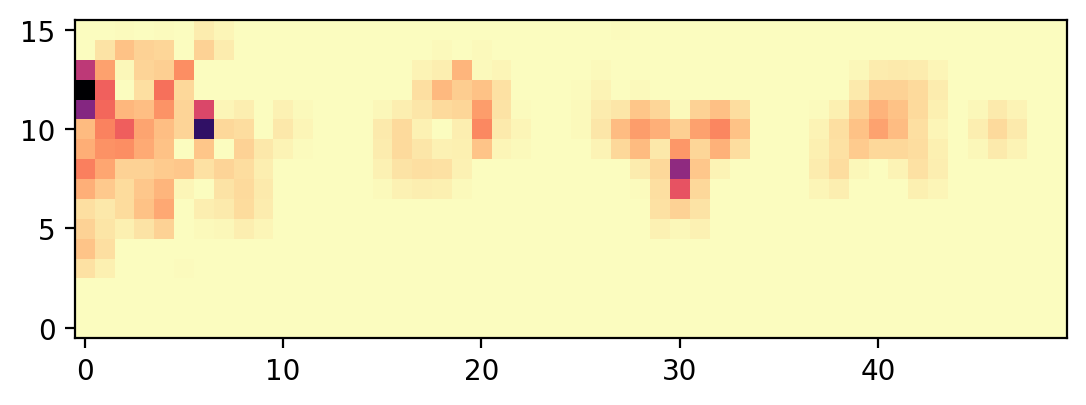

In [198]:
pred_G_vec = np.matmul(deconv_model.H, f)
pred_G_coeffs_mats = chrom_wavelets.convert_vectorized_coeffs_to_mat(pred_G_vec)
pred_G_coeffs_mats.shape

pred_G_imgs = chrom_wavelets.reconstruct_images(pred_G_coeffs_mats)
pred_G_imgs.shape

plt_img = pred_G_imgs[0].copy()
plt_img[plt_img < 0] = 0
plt.imshow(plt_img, cmap='magma_r', origin='lower')

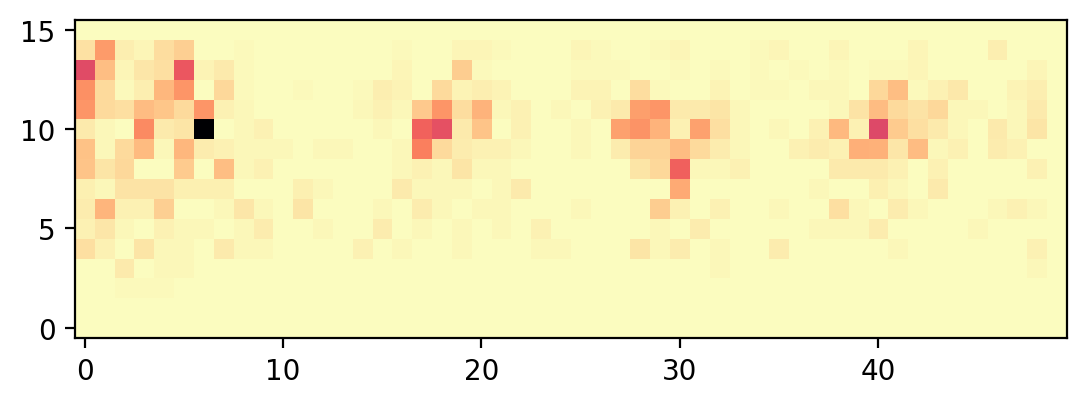

In [199]:
plt.imshow(chromatin_model.deconv_hist_unflattened[0], cmap='magma_r', origin='lower')